# ZINC Michael acceptors

## Import necessary packages

In [18]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from tqdm import tqdm
import io, os
import requests
from huggingface_hub import hf_hub_url
from pandarallel import pandarallel

import random
import numpy as np
seed = 10 #42
random.seed(seed)
np.random.seed(seed)

## Sample 2.5k from within each tranche of ZINC

Important note: we ensure that all sampled compounds taken from the original ZINC source are no more than 500 g/mol in size (MolWt) to ensure that the distribution of molecular sizes is not heavily right-skewed. This makes the distribution of SMILES string lengths more normal, and reduces the max string length that sets the whitespace padding for all other strings. We additionally restrict max SMILES string length to be 100 characters.

Extra note: Before filtering for MolWt, we noticed an unnatural "cliff" in the MolWt distribution, suggesting that ZINC was intended to comply with this MolWt cutoff, but that some outliers (heavy molecules) in ZINC were not removed during its creation.

In [ ]:
from rdkit.Chem.Descriptors import ExactMolWt

chunks = [f'{n:02}' for n in range(100)]
N = 250_000
n = int(250_000 / len(chunks))

filter_weights = True

dfs = []
for chunk in tqdm(chunks[:]):

    df = pd.read_csv(f'ZINC/tranches/ZINC_{chunk}_Michael.csv.gz')

    # print('The number of Michael acceptors is', len(df['smiles']))

    if filter_weights:
        frac = 10_000 / len(df['smiles'])
        df_sample = df.sample(frac= frac, random_state=10) #42
        df_sample["MolWt"] = df_sample["smiles"].apply(lambda x: ExactMolWt(Chem.MolFromSmiles(x)))
        df_sample["len"] = df_sample["smiles"].apply(len)
        df_sample = df_sample[df_sample["MolWt"] <= 500] # we set an upper-limit on MolWt to avoid very long SMILES strings
        df_sample = df_sample[df_sample["len"] <= 100] # another filter for string length
        # todo: add another filter for molecular complexity (optional)
        df_sample = df_sample.iloc[:n]
    else:
        frac = 2_500 / len(df['smiles'])
        df_sample = df.sample(frac= frac, random_state=10) #42

    dfs.append(df_sample)



100%|██████████| 100/100 [02:07<00:00,  1.27s/it]


## Combine sub-dataframes into one 250k dataframe

In [23]:
chunks = [f'{n:02}' for n in range(100)]

ZINC_Michael_250k = pd.concat(dfs, ignore_index=True)

if "MolWt" in ZINC_Michael_250k.columns:
    ZINC_Michael_250k = ZINC_Michael_250k.drop(columns="MolWt", axis=1)
if "len" in ZINC_Michael_250k.columns:
    ZINC_Michael_250k = ZINC_Michael_250k.drop(columns="len", axis=1)

print(len(ZINC_Michael_250k['smiles']))
ZINC_Michael_250k.head()


250000


,smiles,id,selfies
0,c1cc(oc1)/C=C\C(=O)N2C[C@@H]3C[C@@]3(C2)CO,ZINC000783781422_1,[C][C][=C][Branch1][Branch1][O][C][=Ring1][Bra...
1,CN(C[C@H](C1CC1)O)C(=O)/C=C\c2cccnc2,ZINC000690304929_1,[C][N][Branch1][O][C][C@H1][Branch1][=Branch1]...
2,CSc1cc(ccc1Cl)NC(=O)C=C2CCSCC2,ZINC000840509118_1,[C][S][C][=C][C][=Branch1][#Branch1][=C][C][=C...
3,CC/C=C(/C)\C(=O)NCCC[NH2+]C[C@H](C)OC,ZINC001155291871_1,[C][C][/C][=C][Branch1][C][/C][\C][=Branch1][C...
4,CN(Cc1cccc(c1)c2n[n-]nn2)C(=O)C=C,ZINC000095314756_1,[C][N][Branch2][Ring1][Ring1][C][C][=C][C][=C]...


## Save large dataframe 
### (e.g. as ZINC_Michael_250k.csv.gz)

In [ ]:
filename = 'ZINC_Michael_250k_500_100.csv.gz' # rename this (warning: will overwrite if file already exists)
ZINC_Michael_250k.to_csv(os.path.join('data','ZINC',filename),index=False)

## Analyze data
### (e.g. visualize a few random molecules using RDKit)

In [25]:
from rdkit.Chem import Draw

ZINC_Michael_250k['mols'] = ZINC_Michael_250k['smiles'].apply(lambda x: Chem.MolFromSmiles(x))


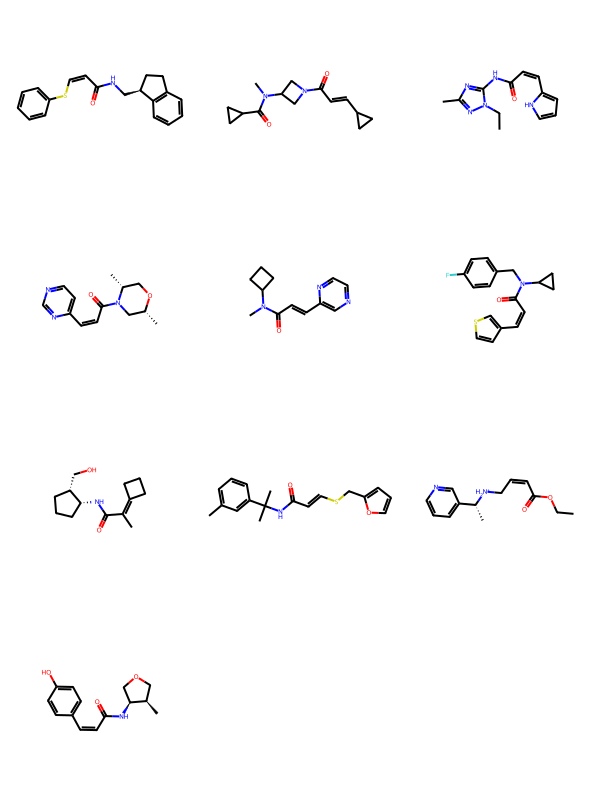

In [26]:
Draw.MolsToGridImage(ZINC_Michael_250k['mols'][10:20])

In [28]:
ZINC_Michael_250k = pd.read_csv(os.path.join('data','ZINC','ZINC_Michael_250k_500_100.csv.gz'))
ZINC_Michael_250k.head()

,smiles,id,selfies
0,c1cc(oc1)/C=C\C(=O)N2C[C@@H]3C[C@@]3(C2)CO,ZINC000783781422_1,[C][C][=C][Branch1][Branch1][O][C][=Ring1][Bra...
1,CN(C[C@H](C1CC1)O)C(=O)/C=C\c2cccnc2,ZINC000690304929_1,[C][N][Branch1][O][C][C@H1][Branch1][=Branch1]...
2,CSc1cc(ccc1Cl)NC(=O)C=C2CCSCC2,ZINC000840509118_1,[C][S][C][=C][C][=Branch1][#Branch1][=C][C][=C...
3,CC/C=C(/C)\C(=O)NCCC[NH2+]C[C@H](C)OC,ZINC001155291871_1,[C][C][/C][=C][Branch1][C][/C][\C][=Branch1][C...
4,CN(Cc1cccc(c1)c2n[n-]nn2)C(=O)C=C,ZINC000095314756_1,[C][N][Branch2][Ring1][Ring1][C][C][=C][C][=C]...


In [ ]:
ZINC_Michael_250k["MolWt"] = ZINC_Michael_250k["smiles"].apply(lambda x: ExactMolWt(Chem.MolFromSmiles(x)))

count    250000.000000
mean        362.342532
std          60.515626
min         108.057515
25%         324.107681
50%         349.223417
75%         403.113667
max         499.986397
Name: MolWt, dtype: float64


<Axes: xlabel='MolWt', ylabel='Count'>

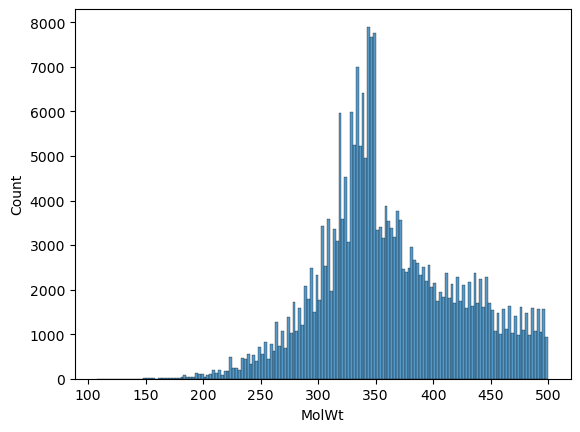

In [15]:
import seaborn as sns
print(ZINC_Michael_250k["MolWt"].describe())
sns.histplot(ZINC_Michael_250k["MolWt"])

In [16]:
ZINC_Michael_250k["len"] = ZINC_Michael_250k["smiles"].apply(len)

count    250000.000000
mean         52.424212
std          10.293006
min          14.000000
25%          45.000000
50%          52.000000
75%          59.000000
max         125.000000
Name: len, dtype: float64


<Axes: xlabel='len', ylabel='Count'>

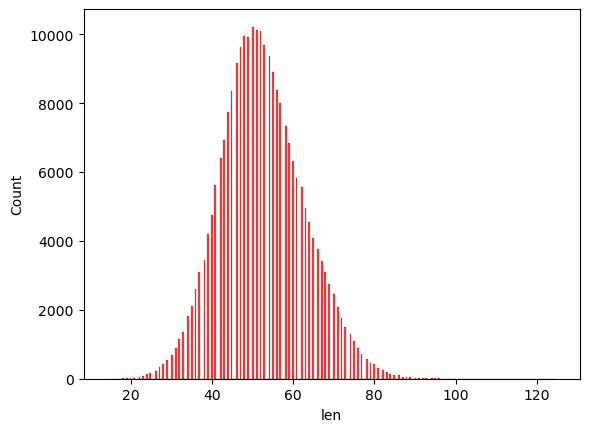

In [17]:
print(ZINC_Michael_250k["len"].describe())
sns.histplot(ZINC_Michael_250k["len"],color="red")